In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import patches
from cmath import rect
%matplotlib inline

Nitrogen - rotation

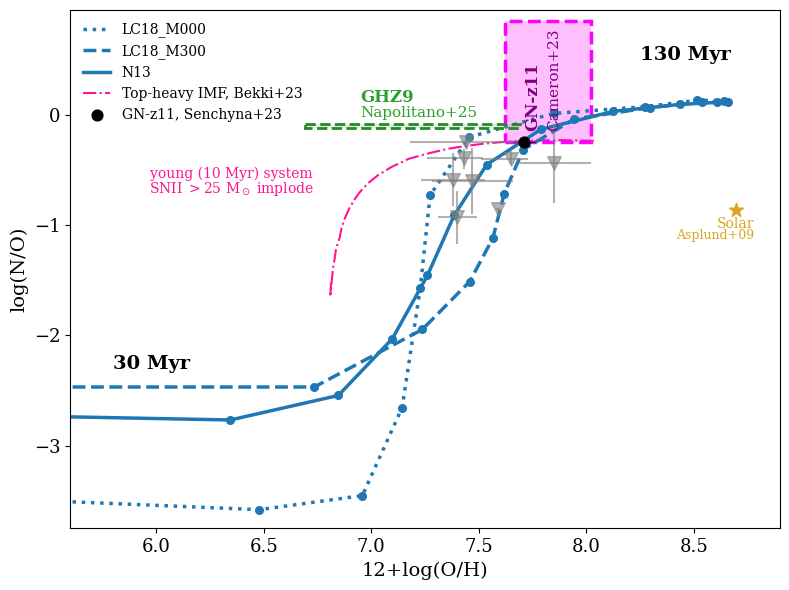

In [14]:
def load_file_paths(base_dir):
    file_paths = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file == "chemical_and_SN_evolution.txt":
                file_paths.append(os.path.join(root, file))
    return file_paths

def load_data_with_names(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data_dict = {}
    for i in range(len(lines)):
        line = lines[i].strip()
        if line.startswith("#"):
            row_name = line[1:].strip()
            if i + 1 < len(lines):
                data = list(map(float, lines[i + 1].strip().split()))
                data_dict[row_name] = data
    return data_dict

def recalculate(logNO, logOH): # Recalculate logNO and logOH
    logNO = [i - 0.86 for i in logNO]
    logOH = [i + 8.696 for i in logOH]
    return logNO, logOH

def fit(logOH, logNO): # Fit a polynomial to the data
    coefficients = np.polyfit(logOH, logNO, deg=6)
    polynomial = np.poly1d(coefficients)
    smooth_logOH = np.linspace(min(logOH[6:]), max(logOH[6:]), 500)
    smooth_logNO = polynomial(smooth_logOH)
    return smooth_logOH, smooth_logNO

def prepare_data(file_paths):
    for path in file_paths:
        data = load_data_with_names(path)
        logNO, logOH = data['Gas [N/O]:'], data['Gas [O/H]:']
        FeH, MgH, OH = data['Gas [Fe/H]:'], data['Gas [Mg/H]:'], data['Gas [O/H]:']
        timestep = data['time step list:']
        logNO_rec, logOH_rec = recalculate(logNO, logOH)
        smooth_logOH, smooth_logNO = fit(logOH_rec, logNO_rec)
    return smooth_logOH, smooth_logNO

def plot_high_redshift_gal_data():
    CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
    # Define data points: (12+O/H, N/O, label, color, err_x, err_y, age, age_err, agn?)
    points = [
        # (8.38, -0.13, 'Mrk 996 (high density)', 0.075, 0.28),
        # (8.36, -1.43, 'Mrk 996 (low density)', 0.225, 0.14),
        # (8.03, -0.21, 'LyC', 0.06, 0.105),
        # (8.00, -0.88, 'ID150880', 0.10, 0.15),
        # ((7.15+7.67)/2, 0.20, 'UNCOvER-45924', 7.67-((7.15+7.67)/2), 0.06),
        # (8.26, -0.93, 'ID1665', 0.15, 0.15),
        # (7.92, -0.85, 'ID1746', 0.13, 0.15),
        # (7.72, -0.62, 'ID1477', 0.09, 0.11),
        # (7.75, -0.76, 'ID60001', 0.03, 0.03),
        # (7.97, -0.86, 'EXCELS-121806', 0.04, 0.10),
        # (7.90, -1.10, 'GS_3073 (low density)', 0.09, 0.12),
        (7.59, -0.85, 'GS_9422 (tentative)', CB_color_cycle[1], [[0.01], [0.01]], [[0], [0]]),
        # (7.96, -0.67, 'ID397', 0.10, 0.14),
        (7.43, -0.39, 'RXJ2248-ID', CB_color_cycle[1], [[0.17], [0.09]] , [[0.10], [0.08]]),
        (7.65, -0.40, 'GLASS_150008', CB_color_cycle[5], [[0.14], [0.08]] , [[0.05], [0.07]]),
        (7.47, -0.6, 'A1703-zdk6', CB_color_cycle[6], [[0.19], [0.19]], [[0.3], [0.3]]),
        (7.85, -0.44, 'GN-z8-LAE', CB_color_cycle[7], [[0.17], [0.17]], [[0.36], [0.36]]),
        # (8.37, -0.01, 'CEERS_01019 (AGN)', 0.13, 0),
        (7.38, -0.59, 'GN-z9p4', CB_color_cycle[3], [[0.15], [0.15]], [[0.24], [0.24]]),
        # (7.49, -0.93, 'GS-z9-0 light-weighted', 0.11, 0.37),
        (7.4, -0.93, 'GS-z9-0', CB_color_cycle[2], [[0.09], [0.09]], [[0.24], [0.24]]),
        # ((6.69+7.69)/2, (-0.08-0.12)/2, 'GHZ9p', CB_color_cycle[2], 0, 0),
        (7.44, -0.25, 'GHZ2/GLASS-z12', CB_color_cycle[8], [[0.26], [0.24]], [[0.05], [0.05]]) 
    ]

    handles = []
    for x, y, label, color, xerr, yerr in points:
        sc = plt.scatter(x, y, color='gray', label=label, s=95, marker='v', zorder=5, alpha=0.6)
        plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none', elinewidth=1.5, ecolor='gray', zorder=5, alpha=0.6)
        handles.append(sc)
    # Custom legend
    # lgd = plt.legend(handles=handles, labels=[p[2] for p in points], bbox_to_anchor=(1.08, 1), loc='upper left', fontsize=8, title="Observational Data")


def plot_Bekki_comparison():
    patha115 = "/Users/adriana_work/Desktop/galIMF/Bekki paper stolen plots/alpha115.csv"
    patha155 = "/Users/adriana_work/Desktop/galIMF/Bekki paper stolen plots/alpha155.csv"
    patha235 = "/Users/adriana_work/Desktop/galIMF/Bekki paper stolen plots/alpha235.csv"
    pathdwarf = "/Users/adriana_work/Desktop/galIMF/Bekki paper stolen plots/dwarf.csv"

    a115 = np.loadtxt(patha115, delimiter=',')
    a155 = np.loadtxt(patha155, delimiter=',')
    a235 = np.loadtxt(patha235, delimiter=',')
    dwarf = np.loadtxt(pathdwarf, delimiter=',')

    BlogOHa115 = a115[:, 0]
    BlogNOa115 = a115[:, 1]
    BlogOHa155 = a155[:, 0]
    BlogNOa155 = a155[:, 1]
    BlogOHa235 = a235[:, 0]
    BlogNOa235 = a235[:, 1]
    BlogOHdwarf = dwarf[:, 0]
    BlogNOdwarf = dwarf[:, 1] 

    plt.rc('font', family='serif')
    # plt.plot(BlogOHa155, BlogNOa155, color='palevioletred', lw=1.1, label='Bekki, $\\alpha=1.55$', linestyle=':')
    plt.plot(BlogOHa115, BlogNOa115, color='deeppink', lw=1.5, label='Top-heavy IMF, Bekki+23', linestyle='-.', zorder=0)
    plt.text(6.35, -0.6, 'young (10 Myr) system', color='deeppink', ha='center', va='bottom', fontsize=10)
    plt.text(6.35, -0.75, 'SNII $>$25 M$_\\odot~$implode', color='deeppink', ha='center', va='bottom', fontsize=10)
    # plt.plot(BlogOHa235, BlogNOa235, color='crimson', lw=1, label='Bekki, $\\alpha=2.35$', linestyle='--')
    # plt.plot(BlogOHdwarf, BlogNOdwarf, color='darkmagenta', lw=1, label='Bekki, dwarf', linestyle='-.')
    Xmin, Xmax = 6.69, 7.69
    Ymin, Ymax = -0.08, -0.12
    rect2 = patches.Rectangle((Xmin, Ymin), Xmax-Xmin, Ymax-Ymin,
                         linewidth=2, facecolor='darkseagreen',
                         alpha=0.25, zorder=10)
    plt.gca().add_patch(rect2)
    rect3 = patches.Rectangle((Xmin, Ymin), Xmax-Xmin, Ymax-Ymin,
                         linewidth=2, edgecolor='forestgreen', facecolor='none',
                         alpha=1, linestyle='--', zorder=10)
    plt.gca().add_patch(rect3)
    plt.text(6.95, 0.12, 'GHZ9', color='tab:green', fontsize=12, weight="bold")
    plt.text(6.95, -0.02, 'Napolitano+25', color='tab:green', fontsize=11)

    xmin, xmax = 7.62, 8.02
    ymin, ymax = -0.25, 0.85
    rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2.5, facecolor='magenta',
                         alpha=0.25, zorder=0)
    plt.gca().add_patch(rect)
    rect1 = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2.5, edgecolor='magenta', facecolor='none',
                         alpha=1, linestyle='--', zorder=0)
    plt.gca().add_patch(rect1)
    # plt.plot([7.82, 7.92], [-0.25, 0.25], color='purple', linestyle=':', linewidth=2, marker=None)
    plt.text(7.75, - 0.25 + 0.1, 'GN-z11', color='purple', ha='center', va='bottom', fontsize=12, rotation=90, weight="bold", zorder=10)
    plt.text(7.85, - 0.25 + 0.1, 'Cameron+23', color='purple', ha='center', va='bottom', fontsize=11, rotation=90, zorder=10)
    # plt.scatter(7.84, -0.38, color='black', label='GN-z11', s=30, marker='*') # from Senchyna23 https://arxiv.org/pdf/2303.04179 (gas + dust)
    plt.scatter(7.71, -0.25, color='black', label='GN-z11, Senchyna+23', s=60, marker='o', zorder=5) # gas-phase only (Senchyna23), BEAGLE line fitting
    plt.errorbar(7.71, -0.25, 0.05, 0.05, fmt='none', elinewidth=0.8, ecolor='black', zorder=5)
    plt.scatter(8.696, -0.86, color='goldenrod', s=110, marker='*')
    plt.text(8.696, -1.05, 'Solar', color='goldenrod', ha='center', va='bottom', fontsize=10)
    plt.text(8.6, -1.15, 'Asplund+09', color='goldenrod', ha='center', va='bottom', fontsize=9)
    # ax = plt.gca()
    # ax.axhline(-0.86, color='red', linestyle='--', linewidth=0.5, label='Solar')
    # ay = plt.gca()
    # ay.axvline(8.696, color='red', linestyle='--', linewidth=0.5)
    # plt.scatter(7.91, -0.2, color='red', label='GN-z11', s=30, marker='*')

  # Extend if needed
plt.rc('font', family='serif')
plt.figure(figsize=(8, 6))

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/LC18_M000_sup_agb/igimf2/imfigimfLog_SFR0.3SFEN100SFE0.008infall0.0065outf110/chemical_and_SN_evolution.txt")
index_x=2
index_y=13

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logNO, logOH = data['Gas [N/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logNO, logOH = recalculate(logNO, logOH)
    plt.scatter(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:blue', s=30)
    plt.plot(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:blue', lw=2.5, label='LC18_M000', linestyle="dotted")

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/LC18_M300_sup_agb/igimf2/imfigimfLog_SFR0.3SFEN100SFE0.008infall0.0065outf110/chemical_and_SN_evolution.txt")
index_x=1
index_y=13

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logNO, logOH = data['Gas [N/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logNO, logOH = recalculate(logNO, logOH)
    plt.scatter(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:blue', s=30)
    plt.plot(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:blue', lw=2.5, label='LC18_M300', linestyle="--")

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/igimf2/imfigimfSTF0.04Log_SFR0.3SFEN100SFE0.008Z_0-4.15infall0.0065/chemical_and_SN_evolution.txt")
index_x=2
index_y=13

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logNO, logOH = data['Gas [N/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logNO, logOH = recalculate(logNO, logOH)
    plt.scatter(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:blue', s=30)
    plt.plot(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:blue', lw=2.5, label='N13')

plt.text(5.8, -2.3, '30 Myr', color='black', fontsize=14, weight="bold")    
plt.text(8.25, 0.5, '130 Myr', color='black', fontsize=14, weight="bold")       

# plt.text(7.95, -2.5, 'Nomoto+13', color='tab:blue', ha='center', va='bottom', fontsize=17, weight="bold") 

title='Chemical evolution models with different IMF slopes'
filename='./paper/paper_nitrogen_rotation.pdf'
plot_Bekki_comparison()
plt.xlabel('12+log(O/H)', fontsize=14)
plt.ylabel('log(N/O)', fontsize=14)
plt.xlim(5.6, 8.9)
plt.locator_params(axis='x', nbins=8)
plt.ylim(-3.75, 0.95)
plt.locator_params(axis='y', nbins=8)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(bbox_to_anchor=(0, 1), loc="upper left", fontsize=10, frameon=False)
# lgd_obs = plot_high_redshift_gal_data()
# plt.gca().add_artist(lgd_obs)
plot_high_redshift_gal_data()
# plt.title(title, fontsize=16)
plt.savefig(filename, bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

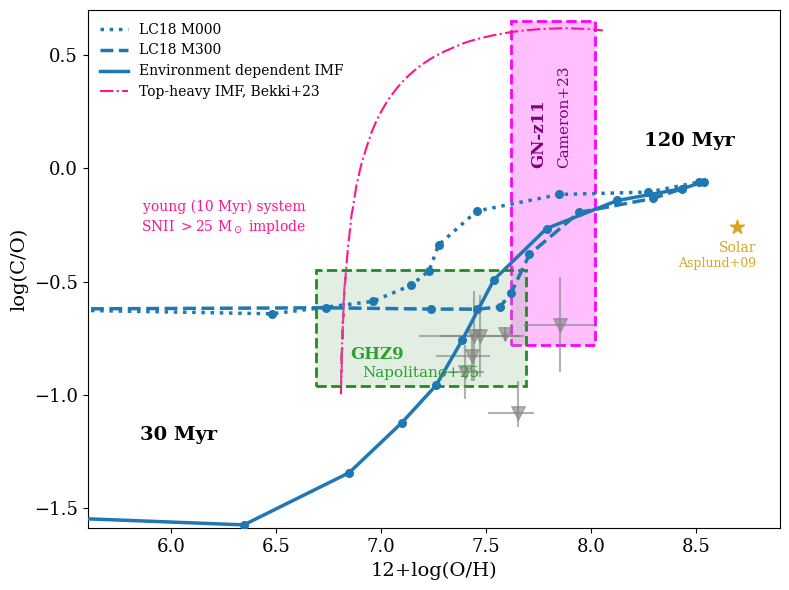

In [3]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import patches
from cmath import rect
from matplotlib.colors import ListedColormap

import os
%matplotlib inline

def load_file_paths(base_dir):
    file_paths = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file == "chemical_and_SN_evolution.txt":
                file_paths.append(os.path.join(root, file))
    return file_paths

def load_data_with_names(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data_dict = {}
    for i in range(len(lines)):
        line = lines[i].strip()
        if line.startswith("#"):
            row_name = line[1:].strip()
            if i + 1 < len(lines):
                data = list(map(float, lines[i + 1].strip().split()))
                data_dict[row_name] = data
    return data_dict

def recalculate(logCO, logOH):
    logCO = [i - 0.26 for i in logCO]
    logOH = [i + 8.696 for i in logOH]
    return logCO, logOH

def plot_Bekki_comparison():
    path = "/Users/adriana_work/Desktop/galIMF/Bekki paper stolen plots/alpha115_carbon.txt"
    data = np.loadtxt(path, delimiter=',')
    OH = data[:, 0]
    CO = data[:, 1]
    plt.plot(OH, CO, color='deeppink', lw=1.5, label='Top-heavy IMF, Bekki+23', linestyle='-.', zorder=0)
    plt.text(6.25, -0.2, 'young (10 Myr) system', color='deeppink', ha='center', va='bottom', fontsize=10)
    plt.text(6.25, -0.3, 'SNII $>$25 M$_\\odot~$implode', color='deeppink', ha='center', va='bottom', fontsize=10)

def plot_Cameron_carbon():
    xmin, xmax = 7.62, 8.02
    ymin, ymax = -0.78, 0.65
    rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2, facecolor='magenta',
                         alpha=0.25, zorder=0)
    plt.gca().add_patch(rect)
    rect1 = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2, edgecolor='magenta', facecolor='none',
                         alpha=1, linestyle='--', zorder=0)
    plt.gca().add_patch(rect1)
    # plt.plot([7.82, 7.92], [-0.25, 0.25], color='purple', linestyle=':', linewidth=2, marker=None)
    plt.text(7.75, 0, 'GN-z11', color='purple', ha='center', va='bottom', fontsize=12, rotation=90, weight="bold")
    plt.text(7.87, 0, 'Cameron+23', color='purple', ha='center', va='bottom', fontsize=11, rotation=90)

def plot_high_redshift_data_Ji25():
    # Define data points: (12+O/H, C/O, label, color, err_x, err_y, z)
    CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
    points = [
        # (8.38, -, 'Mrk 996 (high density)', cmap(0), 0.075, 0.28),
        # (8.36, -0.22, 'Mrk 996 (low density)', 0.225, 0.25, 0.00544),
        # (8.03, -0.51, 'LyC (high density)', 0.06, 0.05, 2.37),
        # # (8.00, -, 'ID150880', cmap(4), 0.10, 0.15),
        # ((7.15+7.67)/2, -0.06, 'UNCOvER-45924', 7.67-((7.15+7.67)/2), 0.055, 4.4655),
        # # (8.26, -, 'ID1665', cmap(6), 0.15, 0.15),
        # # (7.92, -, 'ID1746', cmap(7), 0.13, 0.15),
        # # (7.72, -, 'ID1477', cmap(8), 0.09, 0.11),
        # # (7.75, -, 'ID60001', cmap(9), 0.03, 0.03),
        # (7.97, -1.02, 'EXCELS-121806', 0.045, 0.22, 5.225),
        # (8, -0.38, 'GS_3073 (high density)', 0.115, 0.12, 5.55),
        (7.59, -0.73, 'GS_9422 (tentative)', CB_color_cycle[1], [[0.01], [0.01]] , [[0.03], [0.03]]),
        # # (7.96, -0.67, 'ID397', cmap(14), 0.10, 0.14),
        (7.43, -0.83, 'RXJ2248-ID', CB_color_cycle[1], [[0.17], [0.09]] , [[0.11], [0.10]]),
        (7.65, -1.08, 'GLASS_150008', CB_color_cycle[5], [[0.14], [0.08]] , [[0.06], [0.14]]),
        (7.47, -0.74, 'A1703-zdk6', CB_color_cycle[6], [[0.19], [0.19]], [[0.18], [0.18]]),
        (7.85, -0.69, 'GN-z8-LAE', CB_color_cycle[7], [[0.17], [0.17]], [[0.21], [0.21]]),
        # (8.37, -0.36, 'CEERS_01019 (AGN)', 0.135, 0, 8.679),
        # (7.94, -1.04, 'CEERS_01019 (SF)', 0.385, 0, 8.679),
        # (7.38, -1.18, 'GN-z9p4', CB_color_cycle[3], 0.15, 0, 9.380),
        # (7.49, -0.9, 'GS-z9-0 light-weighted', 0.13, 0.26, 9.4327),
        (7.4, -0.9, 'GS-z9-0', CB_color_cycle[2], [[0.09], [0.09]], [[0.12], [0.12]]),
        (7.44, -0.74, 'GHZ2/GLASS-z12', CB_color_cycle[8], [[0.26], [0.24]], [[0.2],[0.2]])
    ]

    xmin, xmax = 6.69, 7.69
    ymin, ymax = -0.96, -0.45
    rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2, facecolor='darkseagreen',
                         alpha=0.25, zorder=5)
    plt.gca().add_patch(rect)
    rect1 = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2, edgecolor='forestgreen', facecolor='none',
                         alpha=1, linestyle='--', zorder=5)
    plt.gca().add_patch(rect1)
    # plt.plot([7.82, 7.92], [-0.25, 0.25], color='purple', linestyle=':', linewidth=2, marker=None)
    plt.text(6.98, -0.86, 'GHZ9', color='tab:green', ha='center', va='bottom', fontsize=12, weight="bold", zorder=10)
    plt.text(7.19, -0.935, 'Napolitano+25', color='tab:green', ha='center', va='bottom', fontsize=11, zorder=10)
    plt.scatter(8.696, -0.26, color='goldenrod', s=110, marker='*')
    plt.text(8.696, -0.38, 'Solar', color='goldenrod', ha='center', va='bottom', fontsize=10)
    plt.text(8.6, -0.45, 'Asplund+09', color='goldenrod', ha='center', va='bottom', fontsize=9)
    handles = []
    for x, y, label, color, xerr, yerr in points:
        sc = plt.scatter(x, y, color='gray', s=95, marker='v', zorder=5, alpha=0.6)
        plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none', elinewidth=1.5, ecolor='gray', zorder=5, alpha=0.6)
        handles.append(sc)


colours = colors = plt.get_cmap('tab10').colors  # Extend if needed
plt.rc('font', family='serif')
plt.figure(figsize=(8, 6))

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/LC18_M000_sup_agb/igimf2/imfigimfLog_SFR0.3SFEN100SFE0.008infall0.0065outf110/chemical_and_SN_evolution.txt")
index_x = 1
index_y = 12

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logCO, logOH = data['Gas [C/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logCO, logOH = recalculate(logCO, logOH)
    # smooth_logOH, smooth_logNO = fit(logOH, logNO)
    # plt.plot(smooth_logOH[index_x:index_y], smooth_logNO[index_x:index_y], color=colors[i % len(colors)], lw=0.8, label=label)
    plt.scatter(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:blue', s=30, zorder=10)
    plt.plot(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:blue', lw=2.5, label='LC18 M000', linestyle="dotted", zorder=10)

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/LC18_M300_sup_agb/igimf2/imfigimfLog_SFR0.3SFEN100SFE0.008infall0.0065outf110/chemical_and_SN_evolution.txt")
index_x = 1
index_y = 12

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logCO, logOH = data['Gas [C/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logCO, logOH = recalculate(logCO, logOH)
    # smooth_logOH, smooth_logNO = fit(logOH, logNO)
    # plt.plot(smooth_logOH[index_x:index_y], smooth_logNO[index_x:index_y], color=colors[i % len(colors)], lw=0.8, label=label)
    plt.scatter(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:blue', s=30, zorder=10)
    plt.plot(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:blue', lw=2.5, label='LC18 M300', linestyle="--", zorder=10)

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/igimf2/imfigimfSTF0.04Log_SFR0.3SFEN100SFE0.008Z_0-4.15infall0.0065/chemical_and_SN_evolution.txt")
index_x = 0
index_y = 12

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logCO, logOH = data['Gas [C/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logCO, logOH = recalculate(logCO, logOH)
    # smooth_logOH, smooth_logNO = fit(logOH, logNO)
    # plt.plot(smooth_logOH[index_x:index_y], smooth_logNO[index_x:index_y], color=colors[i % len(colors)], lw=0.8, label=label)
    plt.scatter(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:blue', s=30, zorder=10)
    plt.plot(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:blue', lw=2.5, label='Environment dependent IMF', zorder=10)

plt.text(5.85, -1.2, '30 Myr', color='black', fontsize=14, weight="bold")    
plt.text(8.25, 0.1, '120 Myr', color='black', fontsize=14, weight="bold")

# plt.text(7.95, -1.4, 'Nomoto+13', color='tab:blue', ha='center', va='bottom', fontsize=17, weight="bold") 

filename='./paper/paper_carbon_rotation.pdf'
plt.xlabel('12+log(O/H)', fontsize=14)
plt.ylabel('log(C/O)', fontsize=14)
plt.locator_params(axis='x', nbins=8)
plt.locator_params(axis='y', nbins=8)
plt.xlim(5.6, 8.9)
plt.ylim(-1.59, 0.7)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
# plt.title(title, fontsize=12)
plot_Cameron_carbon()
plot_Bekki_comparison()
plot_high_redshift_data_Ji25()
plt.legend(bbox_to_anchor=(0, 1), loc="upper left", fontsize=10, frameon=False)
plt.savefig(filename, bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

In [70]:
def load_data_with_names(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data_dict = {}
    for i in range(len(lines)):
        line = lines[i].strip()
        if line.startswith("#"):
            row_name = line[1:].strip()
            if i + 1 < len(lines):
                data = list(map(float, lines[i + 1].strip().split()))
                data_dict[row_name] = data
    return data_dict

lifetime = load_data_with_names("/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_lifetime_from_Nomoto_sup_agb/Nomoto_sup_agb_Z=0.0001.txt")
mass = lifetime["mass"]
lifetime = lifetime["lifetime"]

for i in range (29):
    print(lifetime[i]/1e6, np.log10(mass[i]))


5669.999999999986 -1.0969100130080565
5669.999999999986 0.0
2840.9999999999927 0.09691001300805642
1660.999999999992 0.17609125905568124
1075.0000000000011 0.24303804868629444
858.6999999999965 0.2787536009528289
681.899999999999 0.3222192947339193
549.2999999999988 0.3521825181113625
420.1999999999992 0.3979400086720376
269.1999999999996 0.47712125471966244
188.20000000000005 0.5440680443502757
139.8999999999997 0.6020599913279624
108.80000000000014 0.6532125137753437
87.58999999999976 0.6989700043360189
72.45999999999972 0.7403626894942439
61.269999999999975 0.7781512503836436
55.07454375471051 0.8129133566428556
49.50555524383097 0.8450980400142568
44.49968774894079 0.8750612633917001
39.99999999999993 0.9030899869919435
36.754093900536155 0.9294189257142927
33.77158546123586 0.9542425094393249
17.159999999999958 1.1139433523068367
14.119999999999996 1.1760912590556813
11.250000000000004 1.255272505103306
9.975999999999967 1.3010299956639813
7.920999999999984 1.3979400086720377
6.55

Yields

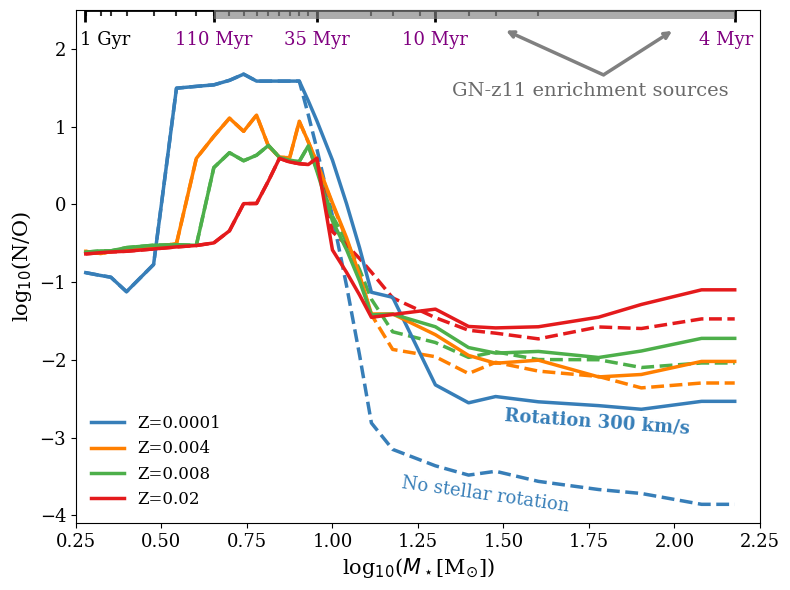

In [4]:
def load_data_with_names(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data_dict = {}
    for i in range(len(lines)):
        line = lines[i].strip()
        if line.startswith("#"):
            row_name = line[1:].strip()
            if i + 1 < len(lines):
                data = list(map(float, lines[i + 1].strip().split()))
                data_dict[row_name] = data
    return data_dict

plt.rc('font', family='serif')
plt.figure(figsize=(8, 6))

file_paths_N = glob.glob('/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_N_eject_mass_from_Limongi_M000_sup_agb/*.txt')
file_paths_O = glob.glob('/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_O_eject_mass_from_Limongi_M000_sup_agb/*.txt')
file_paths_N.sort()
file_paths_O.sort()

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#e41a1c']
for (path_N, path_O), color in zip(zip(file_paths_N, file_paths_O), colors):
    data_N = load_data_with_names(path_N)
    data_O = load_data_with_names(path_O)
    mass = np.array(data_N['mass'])
    N_eject_mass = np.array(data_N['N_eject_mass'])
    O_eject_mass = np.array(data_O['O_eject_mass'])
    # Try to get metallicity from the data, otherwise use filename
    label = data_N.get('metallicity', [None])[0]
    NO_ratio = np.where(O_eject_mass > 0, N_eject_mass / O_eject_mass, np.nan)
    plt.plot(np.log10(mass[5:]), np.log10(NO_ratio[5:]), lw=2.5, linestyle='dashed', color=color)

file_paths_N = glob.glob('/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_N_eject_mass_from_Limongi_M300_sup_agb/*.txt')
file_paths_O = glob.glob('/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_O_eject_mass_from_Limongi_M300_sup_agb/*.txt')
file_paths_N.sort()
file_paths_O.sort()

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#e41a1c']
for (path_N, path_O), color in zip(zip(file_paths_N, file_paths_O), colors):
    data_N = load_data_with_names(path_N)
    data_O = load_data_with_names(path_O)
    mass = np.array(data_N['mass'])
    N_eject_mass = np.array(data_N['N_eject_mass'])
    O_eject_mass = np.array(data_O['O_eject_mass'])
    # Try to get metallicity from the data, otherwise use filename
    label = data_N.get('metallicity', [None])[0]
    NO_ratio = np.where(O_eject_mass > 0, N_eject_mass / O_eject_mass, np.nan)
    plt.plot(np.log10(mass[5:]), np.log10(NO_ratio[5:]), label=f'Z={label}', lw=2.5, color=color)

plt.text(1.2, -3.95, "No stellar rotation", rotation = -8, fontsize=13, color='#377eb8', zorder=8)
plt.text(1.5, -2.95, "Rotation 300 km/s", weight='bold', rotation = -4, fontsize=13, color='#377eb8', zorder=8)

############################################ ticks and fun

xmin, xmax = 0.28, 2.176
yline = 2.5

# Horizontal line
plt.plot([xmin, xmax], [yline, yline], color='black', linewidth=2, zorder=6)

# Tick positions
tick_x = [0.278, 0.6532125137753437, 0.9542425094393249, 1.3010299956639813, 2.176]
tick_height = 0.3

# Ticks
for x in tick_x:
    plt.vlines(x,
            yline - tick_height/2,
            yline + tick_height/2,
            color='black',
            linewidth=2,
            zorder=7)
lifetime = load_data_with_names("/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_lifetime_from_Nomoto_sup_agb/Nomoto_sup_agb_Z=0.0001.txt")
mass = lifetime["mass"]

tick_height = 0.15

# Ticks
for x in np.log10(mass):
    plt.vlines(x,
            yline - tick_height/2,
            yline + tick_height/2,
            color='black',
            linewidth=1.5,
            alpha=0.8,
            zorder=7)

# Age labels
ages = ['', '110 Myr', '35 Myr', '10 Myr', '']
plt.text(0.335, yline - 0.5, "1 Gyr", ha='center', va='bottom', fontsize=13, color='black', zorder=8)
plt.text(2.15, yline - 0.5, "4 Myr", ha='center', va='bottom', fontsize=13, color='purple', zorder=8)

plt.annotate('', xy=(1.5, 2.25), xytext=(1.8, 1.65), arrowprops=dict(facecolor='grey',ec = 'grey', arrowstyle='->', lw=2.5))
plt.annotate('', xy=(2, 2.25), xytext=(1.787, 1.65), arrowprops=dict(facecolor='grey',ec = 'grey', arrowstyle='->', lw=2.5))
plt.text(1.35, 1.4, "GN-z11 enrichment sources", fontsize=14, color='dimgrey', zorder=8)
for x, age in zip(tick_x, ages):
    plt.text(x, yline - 0.5, age,
            ha='center',
            va='bottom',
            fontsize=13,
            color='purple',
            zorder=8)
xmin, xmax = 0.6532125137753437, 2.176
ymin, ymax = 2.38, 2.5
rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                             linewidth=2, facecolor='gray',
                             alpha=0.65, zorder=10)
plt.gca().add_patch(rect)
plt.xlabel("log$_{10}$($M_\\star$[M$_{\\odot}$])", fontsize=15, fontname='serif')
plt.ylabel('log$_{10}$(N/O)', fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlim(0.25, 2.25)
plt.ylim(-4.1, 2.5)
plt.legend(fontsize=12, loc='lower left', frameon=False)
plt.tight_layout()
plt.savefig('/Users/adriana_work/Desktop/galIMF/plotting/paper/NO_yields_Limongi_M_sup_agb.pdf', dpi=300)
plt.show()

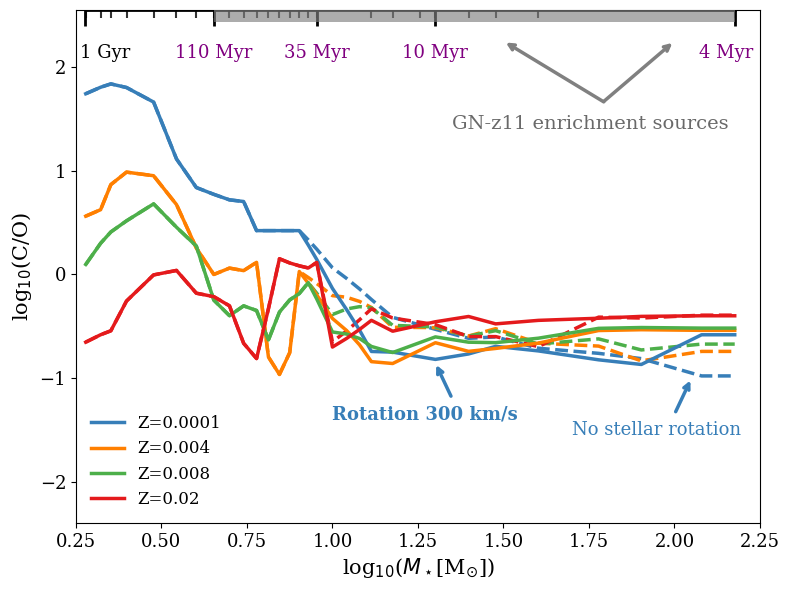

In [6]:
def load_data_with_names(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data_dict = {}
    for i in range(len(lines)):
        line = lines[i].strip()
        if line.startswith("#"):
            row_name = line[1:].strip()
            if i + 1 < len(lines):
                data = list(map(float, lines[i + 1].strip().split()))
                data_dict[row_name] = data
    return data_dict

plt.rc('font', family='serif')
plt.figure(figsize=(8, 6))

file_paths_C = glob.glob('/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_C_eject_mass_from_Limongi_M000_sup_agb/*.txt')
file_paths_O = glob.glob('/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_O_eject_mass_from_Limongi_M000_sup_agb/*.txt')
file_paths_C.sort()
file_paths_O.sort()

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#e41a1c']
for (path_C, path_O), color in zip(zip(file_paths_C, file_paths_O), colors):
    data_C = load_data_with_names(path_C)
    data_O = load_data_with_names(path_O)
    mass = np.array(data_C['mass'])
    C_eject_mass = np.array(data_C['C_eject_mass'])
    O_eject_mass = np.array(data_O['O_eject_mass'])
    # Try to get metallicity from the data, otherwise use filename
    label = data_C.get('metallicity', [None])[0]
    CO_ratio = np.where(O_eject_mass > 0, C_eject_mass / O_eject_mass, np.nan)
    plt.plot(np.log10(mass[5:]), np.log10(CO_ratio[5:]), lw=2.5, linestyle='dashed', color=color)

file_paths_C = glob.glob('/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_C_eject_mass_from_Limongi_M300_sup_agb/*.txt')
file_paths_O = glob.glob('/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_O_eject_mass_from_Limongi_M300_sup_agb/*.txt')
file_paths_C.sort()
file_paths_O.sort()

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#e41a1c']
for (path_C, path_O), color in zip(zip(file_paths_C, file_paths_O), colors):
    data_C = load_data_with_names(path_C)
    data_O = load_data_with_names(path_O)
    mass = np.array(data_C['mass'])
    C_eject_mass = np.array(data_C['C_eject_mass'])
    O_eject_mass = np.array(data_O['O_eject_mass'])
    # Try to get metallicity from the data, otherwise use filename
    label = data_C.get('metallicity', [None])[0]
    CO_ratio = np.where(O_eject_mass > 0, C_eject_mass / O_eject_mass, np.nan)
    plt.plot(np.log10(mass[5:]), np.log10(CO_ratio[5:]), label=f'Z={label}', lw=2.5, color=color)

plt.text(1.7, -1.55, "No stellar rotation", fontsize=13, color='#377eb8', zorder=8)
plt.text(1, -1.4, "Rotation 300 km/s", weight='bold', fontsize=13, color='#377eb8', zorder=8)
plt.annotate('', xy=(2.05, -1), xytext=(2, -1.35), arrowprops=dict(facecolor='#377eb8',ec = '#377eb8', arrowstyle='->', lw=2.5))
plt.annotate('', xy=(1.3, -0.85), xytext=(1.35, -1.2), arrowprops=dict(facecolor='#377eb8',ec = '#377eb8', arrowstyle='->', lw=2.5))

############################################ ticks and fun

xmin, xmax = 0.28, 2.176
yline = 2.55

# Horizontal line
plt.plot([xmin, xmax], [yline, yline], color='black', linewidth=2, zorder=6)

# Tick positions
tick_x = [0.278, 0.6532125137753437, 0.9542425094393249, 1.3010299956639813, 2.176]
tick_height = 0.3

# Ticks
for x in tick_x:
    plt.vlines(x,
            yline - tick_height/2,
            yline + tick_height/2,
            color='black',
            linewidth=2,
            zorder=7)
lifetime = load_data_with_names("/Users/adriana_work/Desktop/galIMF/yield_tables__2024/rearranged___/setllar_lifetime_from_Nomoto_sup_agb/Nomoto_sup_agb_Z=0.0001.txt")
mass = lifetime["mass"]

tick_height = 0.15

# Ticks
for x in np.log10(mass):
    plt.vlines(x,
            yline - tick_height/2,
            yline + tick_height/2,
            color='black',
            linewidth=1.5,
            alpha=0.8,
            zorder=7)

# Age labels
ages = ['', '110 Myr', '35 Myr', '10 Myr', '']
plt.text(0.335, yline - 0.5, "1 Gyr", ha='center', va='bottom', fontsize=13, color='black', zorder=8)
plt.text(2.15, yline - 0.5, "4 Myr", ha='center', va='bottom', fontsize=13, color='purple', zorder=8)

plt.annotate('', xy=(1.5, 2.25), xytext=(1.8, 1.65), arrowprops=dict(facecolor='grey',ec = 'grey', arrowstyle='->', lw=2.5))
plt.annotate('', xy=(2, 2.25), xytext=(1.787, 1.65), arrowprops=dict(facecolor='grey',ec = 'grey', arrowstyle='->', lw=2.5))
plt.text(1.35, 1.4, "GN-z11 enrichment sources", fontsize=14, color='dimgrey', zorder=8)
for x, age in zip(tick_x, ages):
    plt.text(x, yline - 0.5, age,
            ha='center',
            va='bottom',
            fontsize=13,
            color='purple',
            zorder=8)
xmin, xmax = 0.6532125137753437, 2.176
ymin, ymax = 2.43, 2.55
rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                             linewidth=2, facecolor='gray',
                             alpha=0.65, zorder=10)
plt.gca().add_patch(rect)
plt.xlabel("log$_{10}$($M_\\star$[M$_{\\odot}$])", fontsize=15, fontname='serif')
plt.ylabel('log$_{10}$(C/O)', fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlim(0.25, 2.25)
plt.ylim(-2.4, 2.55)
plt.legend(fontsize=12, loc='lower left', frameon=False)
plt.tight_layout()
plt.savefig('/Users/adriana_work/Desktop/galIMF/plotting/paper/CO_yields_Limongi_M_sup_agb.pdf', dpi=300)
plt.show()

Star formation history

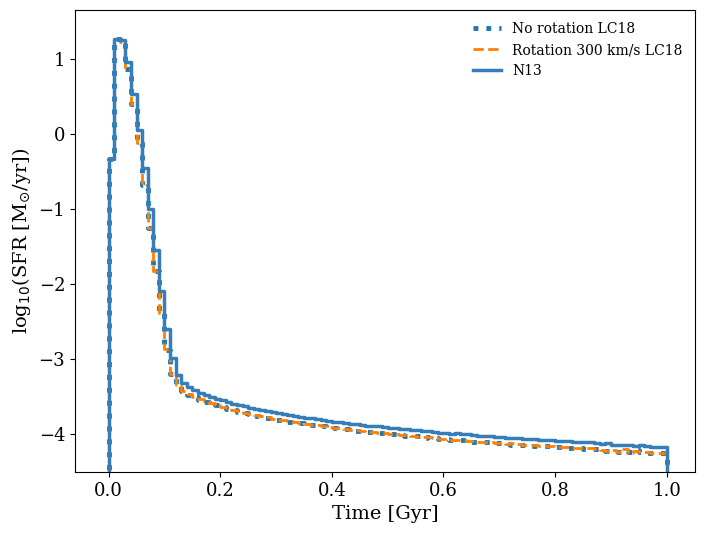

In [15]:
from scipy.integrate import quad
import glob
import numpy as np
import matplotlib.pyplot as plt
import os

def load_data_with_names(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data_dict = {}
    for i in range(len(lines)):
        line = lines[i].strip()
        if line.startswith("#"):
            row_name = line[1:].strip()
            if i + 1 < len(lines):
                data = list(map(float, lines[i + 1].strip().split()))
                data_dict[row_name] = data
    return data_dict

plt.figure(figsize=(8, 6))
plt.rc('font', family='serif')
colours = colors = plt.get_cmap('tab10').colors

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/LC18_M000_sup_agb/igimf2/imfigimfLog_SFR0.3SFEN0.008SFE100infall0.0065outf110/plots/SFH.txt")
min = 0
max = 205
for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    age_list, sfr = data['age_list'], data['SFR_list']
    age_list = np.array(age_list, dtype=float) - 0.01
    plt.plot(age_list[min:max], sfr[min:max], color='tab:blue', lw=3.5, label='No rotation LC18', linestyle="dotted")

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/LC18_M300_sup_agb/igimf2/imfigimfLog_SFR0.3SFEN0.008SFE100infall0.0065outf110/plots/SFH.txt")
min = 0
max = 205
for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    age_list, sfr = data['age_list'], data['SFR_list']
    age_list = np.array(age_list, dtype=float) - 0.01
    plt.plot(age_list[min:max], sfr[min:max], color='#ff7f00', lw=2, label='Rotation 300 km/s LC18', linestyle="--")

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/igimf2/imfigimfSTF-4.15alpha2.3log_SFR<module 'igimf_SFR_-416853_Fe_over_H_-702629' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-416853_Fe_over_H_-702629.py'>SFEN0.3SFE0.008Z_0100infall0.0065/plots/SFH.txt")
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/igimf2/imfigimfLog_SFR0.3SFEN0.008SFE100infall0.009outf100/plots/SFH.txt")
min = 0
max = 205
for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    age_list, sfr = data['age_list'], data['SFR_list']
    age_list = np.array(age_list, dtype=float) - 0.01
    plt.plot(age_list[min:max], sfr[min:max], color='#377eb8', lw=2.5, label='N13')

plt.xlabel('Time [Gyr]', fontsize=14)
plt.ylabel('log$_{10}$(SFR [M$_{\\odot}$/yr])', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.locator_params(axis='x', nbins=8)
plt.ylim(-4.5,1.65)
plt.legend(loc='upper right', fontsize=10, frameon=False)
plt.savefig('/Users/adriana_work/Desktop/galIMF/plotting/paper/sfh_rotation.pdf', bbox_inches='tight', dpi=300)
plt.show()
